# Imports

In [1]:
#set path to DeePEn
import os.path

os.chdir("path to DeePEn")

In [2]:
#import dependencies
import copy
import requests
import zipfile
import io
import json
import math
import os
import subprocess
import sys

import numpy as np
import pandas as pd

from scipy import stats
from scipy.interpolate import make_interp_spline

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.pyplot import cm
import matplotlib.ticker as mtick

import seaborn as sns

In [3]:
# import methods
sys.path.append('./utils')
from DeePEn_evaluate import get_cutoff, load_results, calc_spearman_depthwise, calc_metric_depth, topx_overlap
from DeePEn_analyse import plot_multi_model_multi_metric_DeePEn, table_multi_model_multi_metric_DeePEn

In [4]:
# run prepare_data.py if the splits were not created yet
if not os.path.isdir('./data/splits'):
    subprocess.run(['python', './data/prepare_data.py'])

In [5]:
# Check: If ./results exists, contains main zip shards, and does NOT contain a main directory, unzip
main_zip_1 = './results/main_1.zip'
main_zip_2 = './results/main_2.zip'
main_dir = './results/main'

def unzip(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        zipf.extractall(extract_to)

if os.path.isdir('./results') and os.path.isfile(main_zip_1) and os.path.isfile(main_zip_2) and not os.path.isdir(main_dir):
    unzip(main_zip_1, main_dir)
    unzip(main_zip_2, main_dir)
    print(f'Extracted {main_zip_1.split("/")[-1]} and {main_zip_2.split("/")[-1]} to {main_dir}')
elif os.path.isdir(main_dir):
    print(f'{main_dir} was already extracted previously')    
else:
    print(f'{main_zip} is missing')

./results/main was already extracted previously


# Create display items

In [6]:
# Get a list of all datasets in the directory
files = os.listdir("./data/splits")
files

['CAPSD_AAV2S_Sinai_2021',
 'GFP_AEQVI_Sarkisyan_2016',
 'HIS7_YEAST_Pokusaeva_2019',
 'PHOT_CHLRE_Chen_2023']

## Figures

### Fig. 1a

In [ ]:
# download the complete set of ProteinGym datasets with multiple substitutions (excludes all pure SAV datasets)
def download_and_unzip(url, extract_to):
    # Send a GET request to the URL
    response = requests.get(url)
    
    # Ensure the request was successful
    if response.status_code == 200:
        # Use BytesIO to handle the zip file in memory
        with zipfile.ZipFile(io.BytesIO(response.content)) as zipf:
            # Extract all the contents into the specified directory
            zipf.extractall(extract_to)
    else:
        print(f"Failed to download file, status code: {response.status_code}")


download_url = 'https://marks.hms.harvard.edu/proteingym/ProteinGym_v1.3/cv_folds_multiples_substitutions.zip'
extract_directory = './data'  
download_and_unzip(download_url, extract_directory)

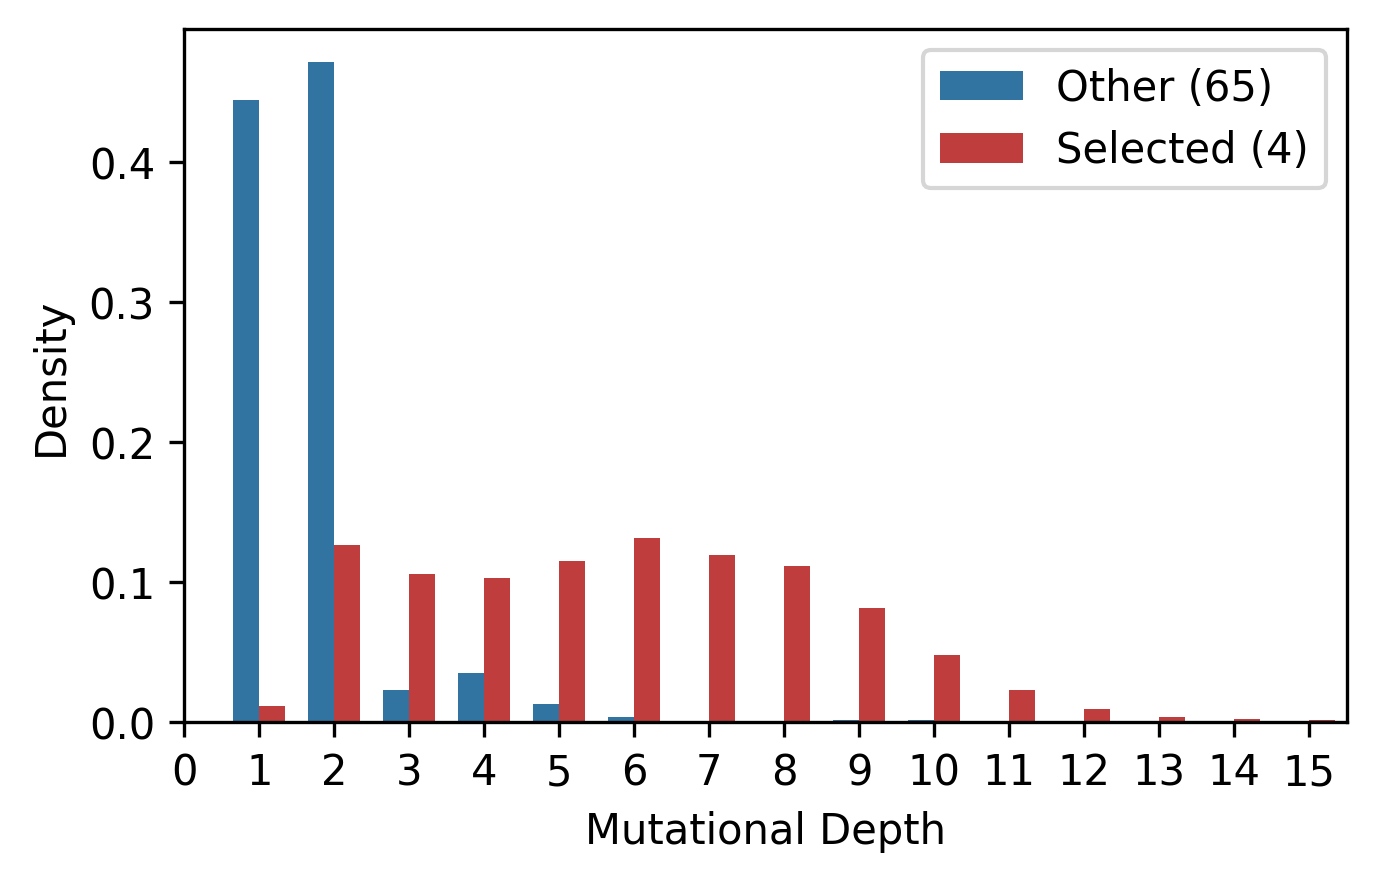

In [8]:
# Specify the directory containing CSV files
directory_path = './data/cv_folds_multiples_substitutions'

def get_density_df(path, files, exclude=True):
    # Maximum mutation depth
    max_mutation_depth = 44

    # List to store DataFrames
    df_list = []

    # Iterate over each file in the directory
    for filename in os.listdir(path):
        # check wether to include or exclude the dataset based on files
        if ((exclude and not any(name in filename for name in files)) or
            (not exclude and any(name in filename for name in files))):
        
            if filename.endswith('.csv'):
                file_path = os.path.join(path, filename)
                # Read CSV file into DataFrame
                df = pd.read_csv(file_path)

                # Group by 'mutation_depth' and get count
                grouped = df.groupby('mutation_depth').size().reset_index(name='count')

                # Create a complete range of mutation depths
                all_depths = pd.DataFrame({'mutation_depth': range(max_mutation_depth + 1)})

                # Merge with the grouped data to fill missing depths with zero counts
                complete_grouped = pd.merge(all_depths, grouped, on='mutation_depth', how='left').fillna(0)

                # Calculate density (assuming density as proportional to counts)
                complete_grouped['density'] = complete_grouped['count'] / complete_grouped['count'].sum()

                # Append to list
                df_list.append(complete_grouped)

    # Concatenate all DataFrames
    all_data = pd.concat(df_list)
    
    return all_data
    
all_data = get_density_df(directory_path, files, True)
selected = get_density_df(directory_path, files, False)


# Plot average density curves using seaborn
# Add 'group' column as before
all_data['group'] = 'Other (65)'
selected['group'] = 'Selected (4)'

# Combine the data
plot_data = pd.concat([all_data, selected])

plt.figure(figsize=(5, 3), dpi=300)
sns.barplot(
    data=plot_data[plot_data['mutation_depth'] <= 20],
    x='mutation_depth', y='density',
    hue='group',
    estimator='mean', # default anyway
    errorbar=None,
    width=0.7,
    palette={'Other (65)': 'tab:blue', 'Selected (4)': 'tab:red'}
)

plt.xlabel('Mutational Depth')
plt.ylabel('Density')
plt.xlim(0, 15.5)
plt.ylim(0, None)
plt.legend(title=None)
plt.show()

### Fig. 1b

In [9]:
def plot_dms_binary(df):

    df_func = df[df.DMS_score_bin == 1]
    df_non = df[df.DMS_score_bin == 0]

    # Get the data boundaries
    min_val = df.DMS_score.min()
    max_val = df.DMS_score.max()
    min_func = df_func.DMS_score.min()

    # Calculate the proportion of the range below min_func
    total_range = max_val - min_val
    lower_range = min_func - min_val
    proportion_lower = lower_range / total_range

    # Calculate number of bins for each section based on proportion
    lower_bins = int(100 * proportion_lower)
    upper_bins = 100 - lower_bins

    # Create custom bin edges
    bins_before = np.linspace(min_val, min_func, lower_bins + 1)  # +1 for bin edges
    bins_after = np.linspace(min_func, max_val, upper_bins + 1)[1:]  # Start from second element to avoid duplicate

    # Combine the bins
    custom_bins = np.concatenate([bins_before, bins_after])

    # Plot with custom bins
    plt.figure(figsize=(3, 3), dpi=300)
    plt.hist([df_func["DMS_score"], df_non["DMS_score"]], 
             bins=custom_bins, 
             density=True, 
             color=["tab:orange", "tab:grey"], 
             stacked=True, 
             label=['Functional', 'Non-Funct.'],
             alpha=0.7)

    plt.ylabel('Density')
    plt.xlabel("DMS_score")
    plt.legend(loc='upper left', fontsize=9)
    plt.text(0.975, 0.975, 'AVV Capsid', ha='right', va='top', transform=plt.gca().transAxes)


    plt.show()

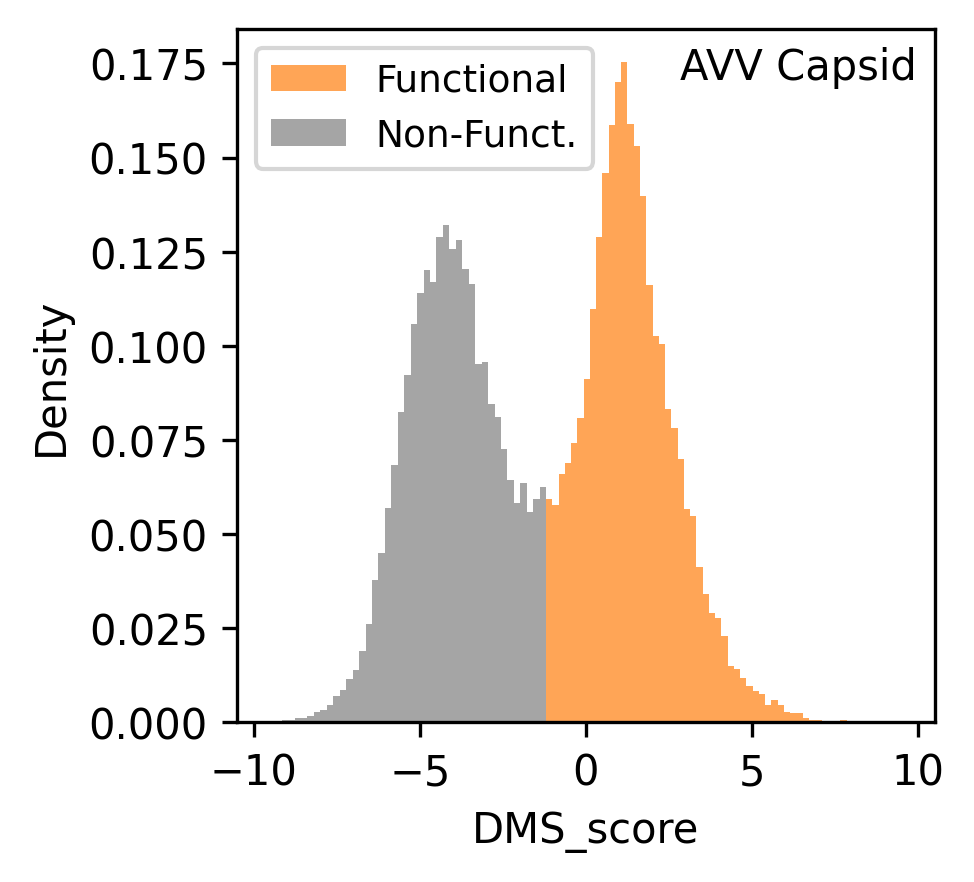

In [10]:
plot_dms_binary(pd.read_csv("./data/raw/CAPSD_AAV2S_Sinai_2021/DMS_raw.csv"))

### Fig. 1c

In [11]:
def plot_files_functional(files):
    plt.figure(figsize=(8.9, 3),dpi=300)  # Create a new figure for all lines
    
    color_list=["tab:red","tab:green","tab:orange","tab:blue"]
    added_names = ["AAV Capsid", "Dehydratase", "GFP", "Phototropin"]
    
    reorder_files = [files[0], files[2], files[1], files[3]]
    
    for f, col, name in zip(reorder_files, color_list, added_names):
        # Read the CSV file
        df = pd.read_csv("./data/raw/" + f + "/DMS_raw.csv", low_memory=False)
        
        df = df[df.set!="wt"]

        # Grouping by 'mutation_depth' and calculating the percentage of 'DMS_score' == 1
        percentage_df = df.groupby('mutation_depth').apply(
            lambda x: (x['DMS_score_bin'] == 1).mean() * 100, include_groups=False
        )

        # Plotting the line plot with a label for each file
        plt.plot(percentage_df.index, percentage_df.values, marker='o', linestyle='-', label=name, alpha=0.5, color=col)

    # General plot settings
    plt.xlim(0, 28)
    plt.ylim(0, 99.5)
    plt.xlabel('Mutational Depth')
    plt.ylabel('Functional variants %')
    plt.grid(True)
    plt.legend()  # Add a legend to identify each line
    plt.show()

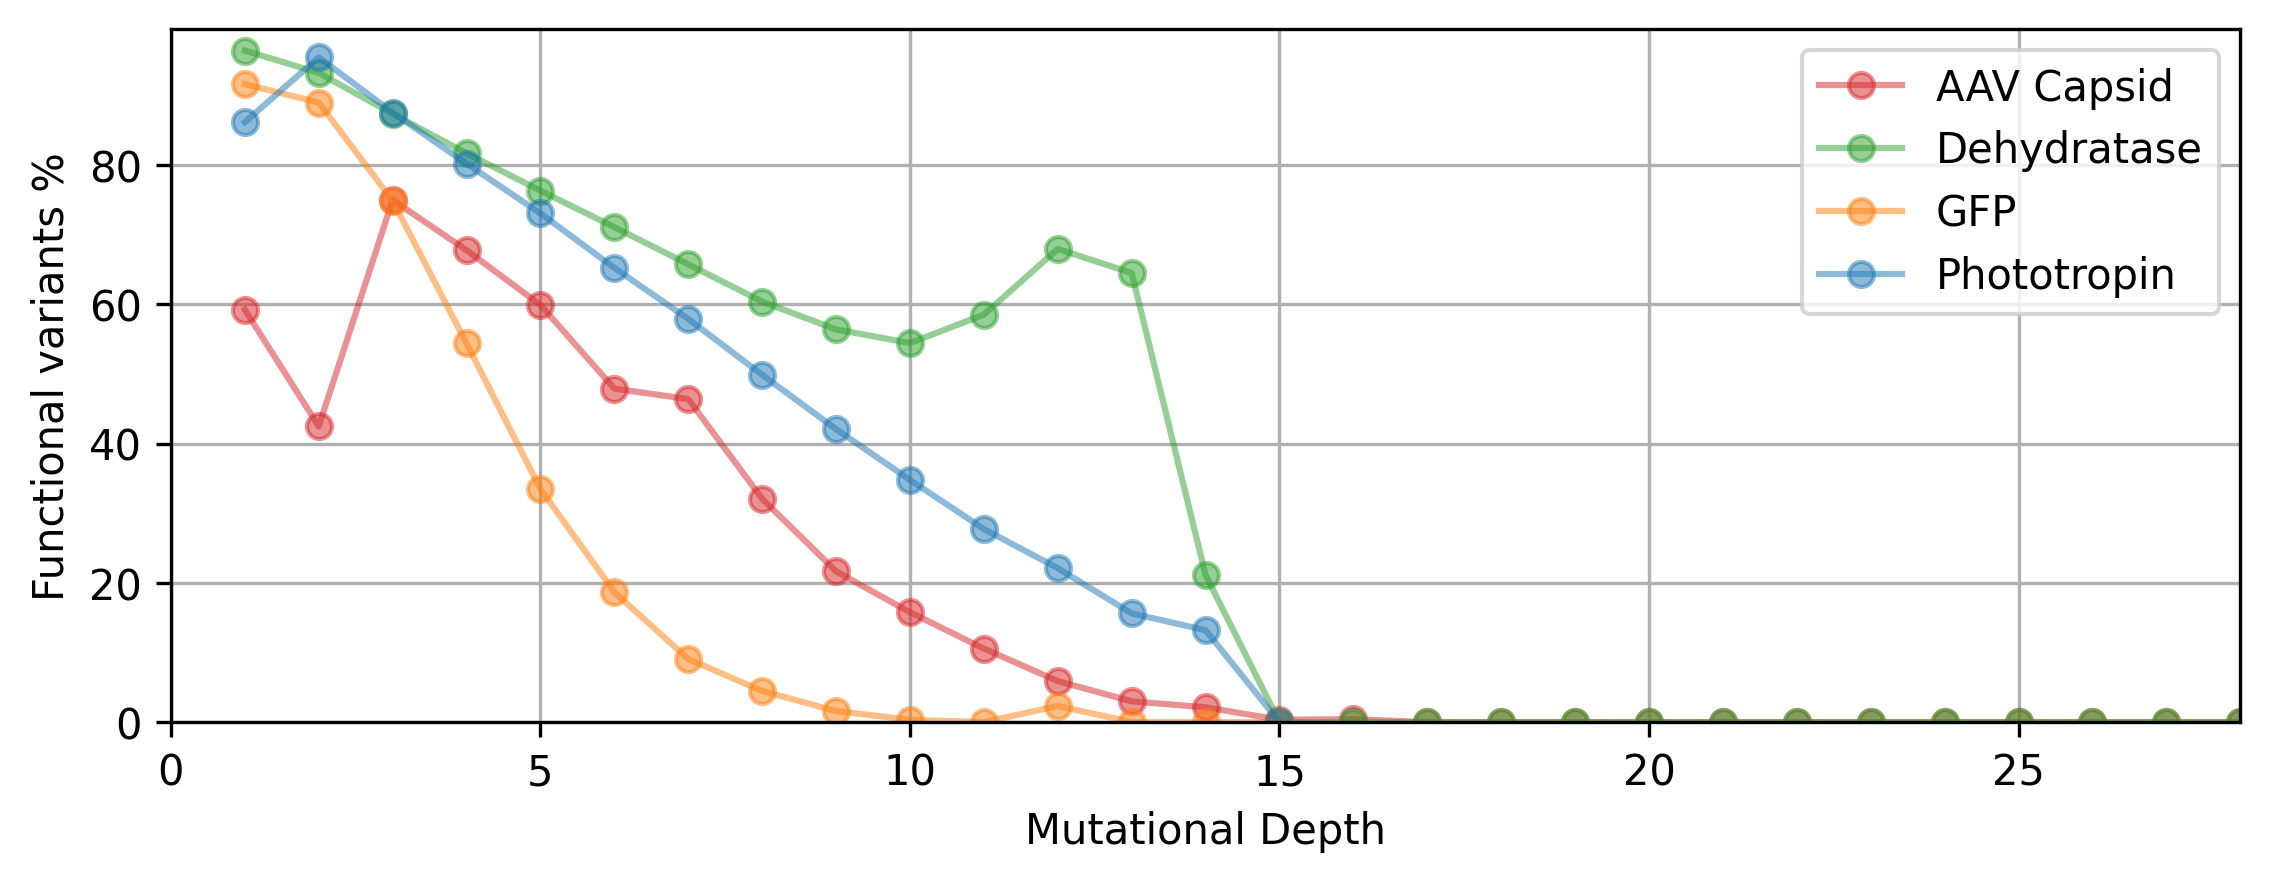

In [12]:
plot_files_functional(files)

### Fig. 2

In [13]:
def plot_depthwise(data, path):
    
    files = os.listdir(path)
    filtered_files = [f for f in files if (data in f) and not ("baseline" in f)]

    depth = list(range(1,len(filtered_files)+1)) 
    
    dfs = []
    
    for d in depth:
        df = calc_spearman_depthwise(path, data, d)
        
        # Identify seed columns (excluding named columns)
        seed_cols = [col for col in df.columns if isinstance(col, int)]
        
        # Calculate standard deviation across numeric columns
        df['std'] = df[seed_cols].std(axis=1)
        
        dfs.append(df)
        
    # Initialize the figure and subplots
    fig, ax = plt.subplots(figsize=(8, 3),dpi=300)

    color=cm.rainbow(np.linspace(0,1,9))
    
    color = color[:int(depth[-1])]
    
    # add Baseline plot    
    df = calc_spearman_depthwise(path, data, 0, baseline=True)   
    ax.plot(df['x'], df['mean'], label="Baseline", marker='o', c="lightgrey")
    # Calculate standard deviation across numeric columns
    df['std'] = df[seed_cols].std(axis=1)
    ax.errorbar(df['x'], df['mean'], yerr=df['std'], 
                   fmt='none', c="lightgrey", 
                   capsize=3, capthick=1, elinewidth=1, alpha=0.7) 
    
    # Plot markers and lines first
    for df, d, c in zip(dfs, depth, reversed(color)):
        if d == 1:
            name = str(d)
        else:
            name = "1 - " + str(d)
            
        ax.plot(df['x'], df['mean'], marker='o', markerfacecolor='none', c=c)
        ax.plot(df['x'][1:], df['mean'][1:], label=name, marker='o', c=c)
    
    # Second pass: Add error bars
    for df, d, c in zip(dfs, depth, reversed(color)):
        ax.errorbar(df['x'], df['mean'], yerr=df['std'], 
                   fmt='none', c=c, 
                   capsize=3, capthick=1, elinewidth=1, alpha=0.7)


    ax.set_xticks([0, 1] + list(dfs[0]['x']))
    ax.set_xticklabels(["WT", 1] + list(dfs[0]['depth']))

    ax.set_xlim(1, df['x'].max()+0.1)
    ax.set_ylim(0, 1)
    
    # Add horizontal grid lines
    ax.grid(axis='y', alpha=0.7, linewidth=0.5)
    
    ax.set_xlabel('Mutational Depth')
    ax.set_ylabel('Spearman')

    handles, labels = ax.get_legend_handles_labels()
    # Move Baseline to the end
    new_handles = handles[1:] + [handles[0]]
    new_labels = labels[1:] + [labels[0]]
    ax.legend(new_handles, new_labels, loc='center left', bbox_to_anchor=(1, 0.55), title='Training depth')
    
    ax.set_title("Phototropin")
    # Adjust layout and show the plot
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

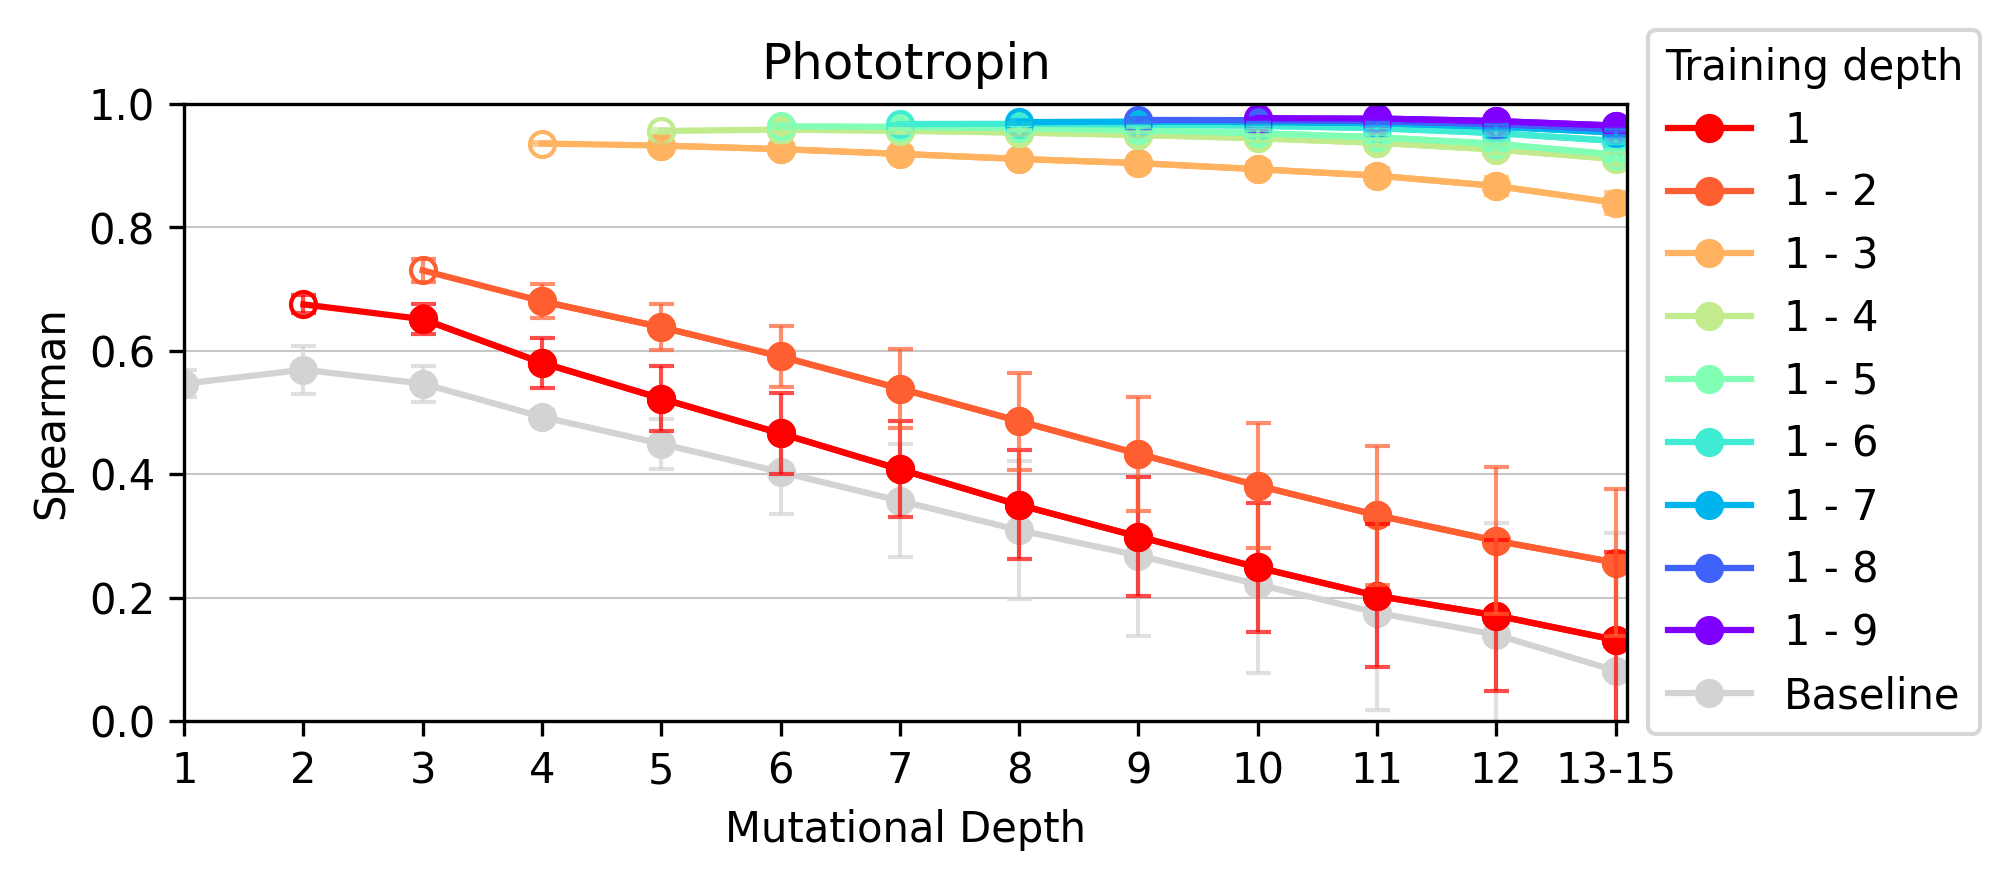

In [14]:
path_main_depthwise = "./results/main/PT5-LoRA_rank_depthwise"

plot_depthwise(files[3], path_main_depthwise)

### Fig. 3

In [15]:
models = ['SBI',
         '1-hot',
         'MAVE-NN_add',
         'MAVE-NN_bb',
         'PT5-LoRA_reg',
         'PT5-LoRA_rank',
         'PT5-Emb',
         'PT5-Emb_evo',
         'METL_1D',
         'METL_3D']

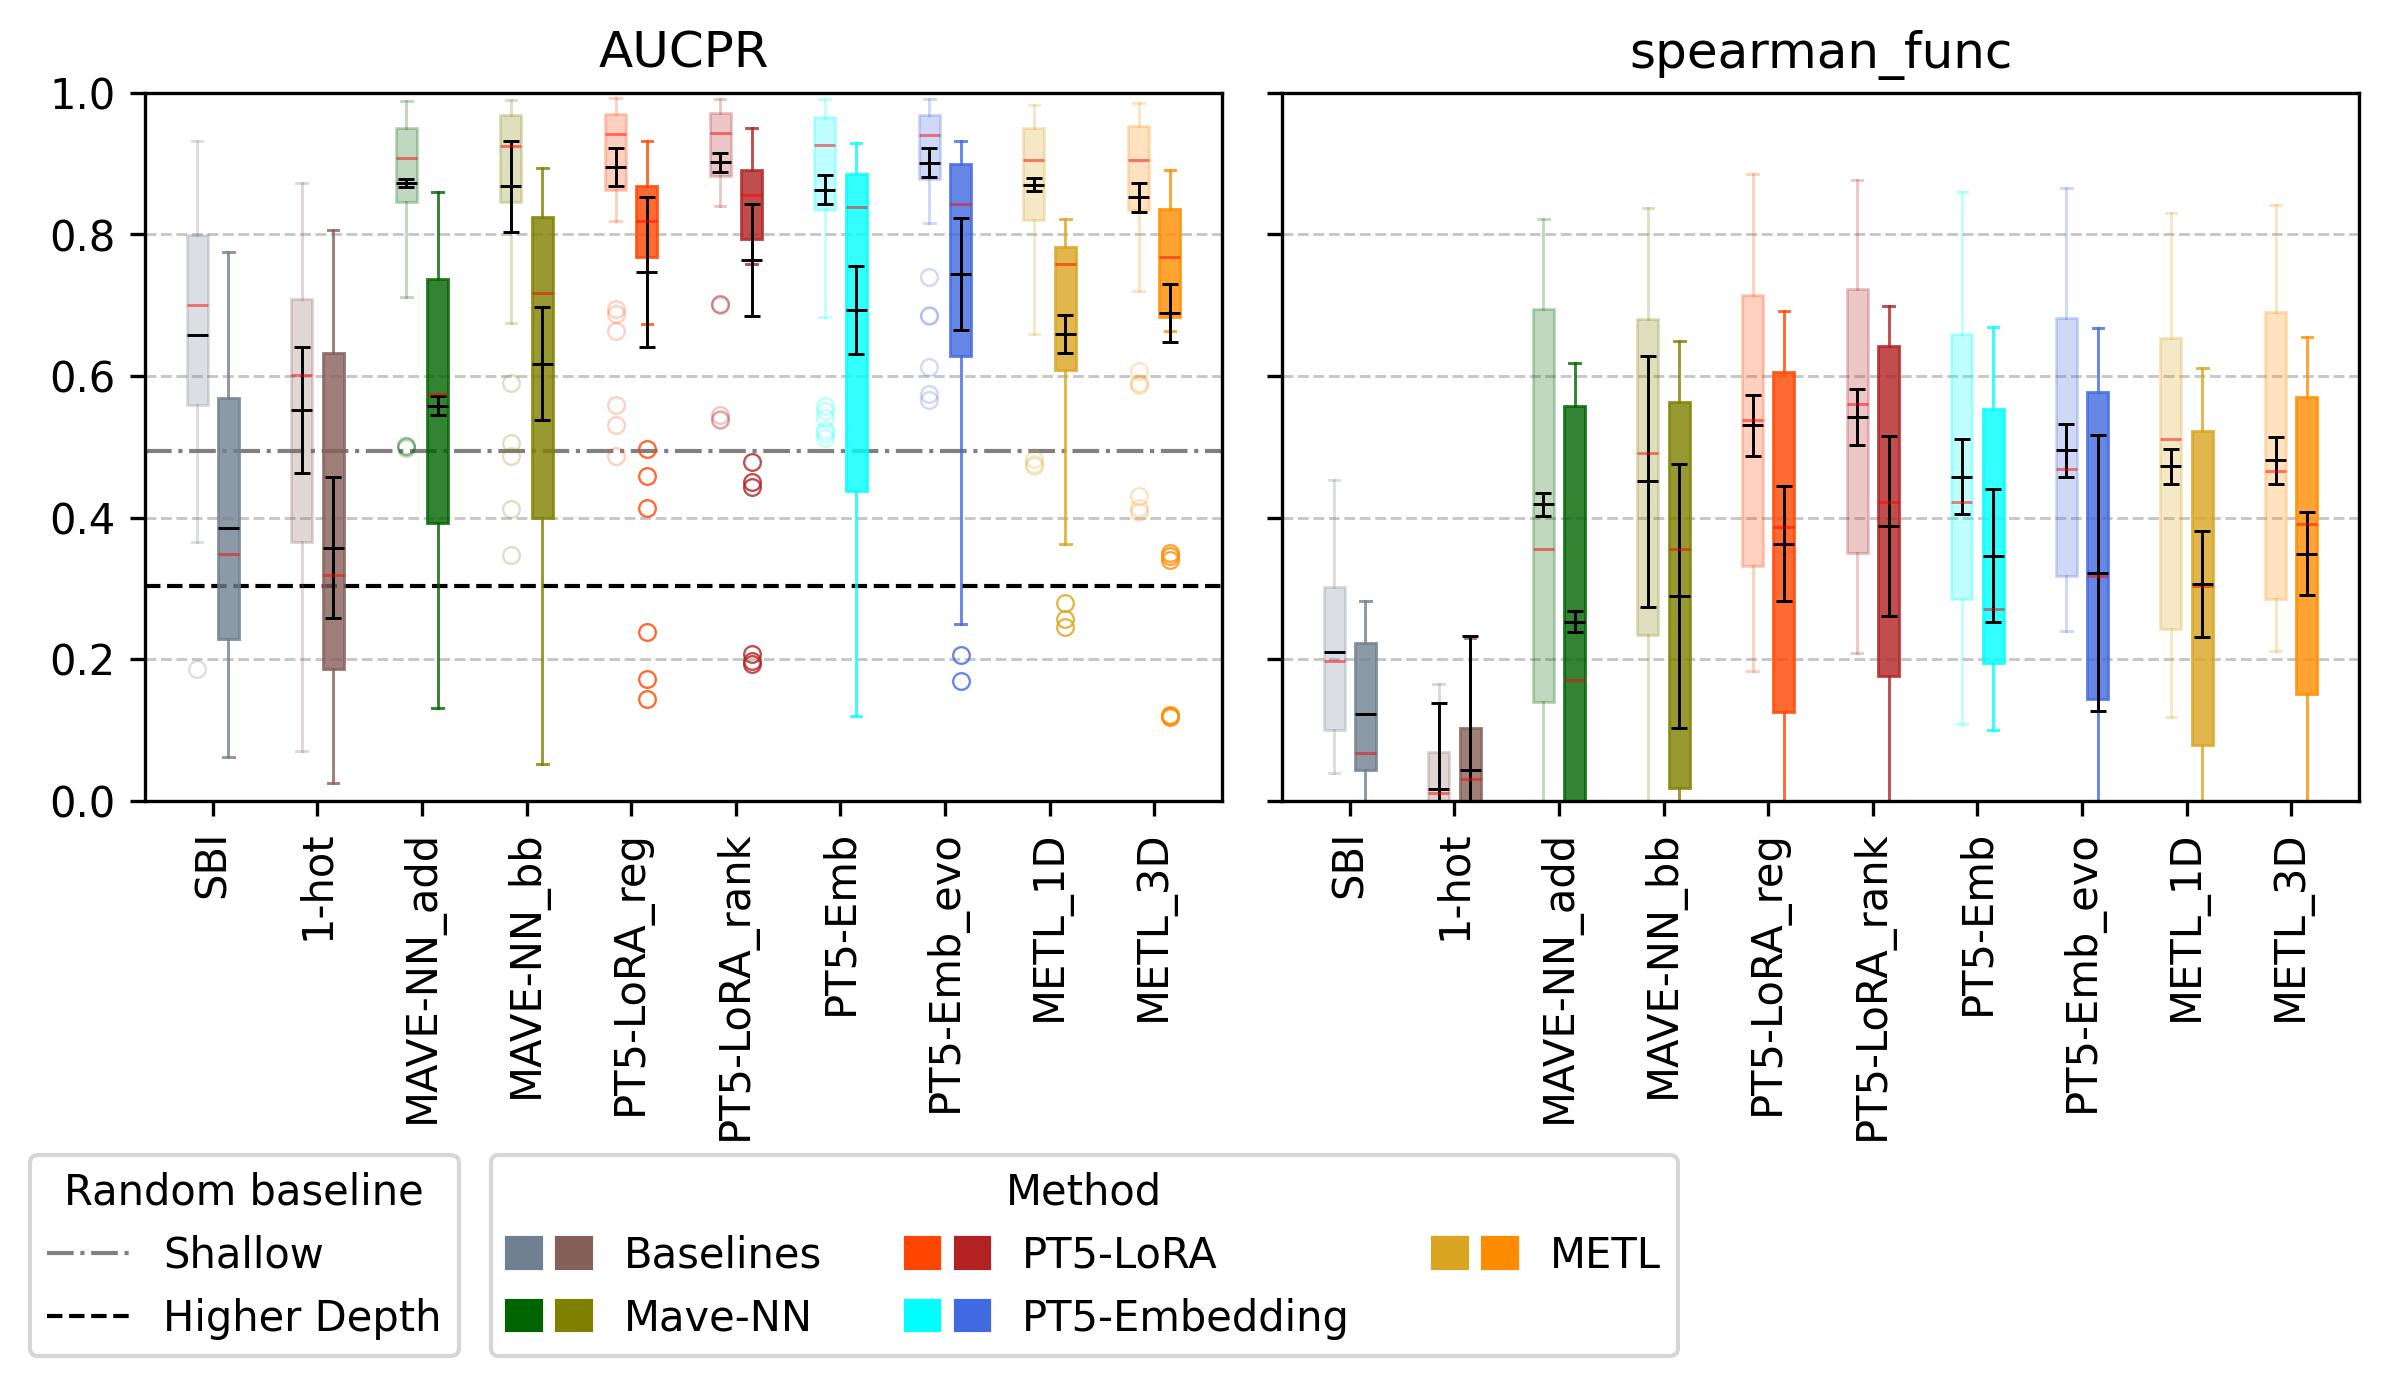

In [16]:
plot_multi_model_multi_metric_DeePEn(models, files, ["AUCPR", "spearman_func"])

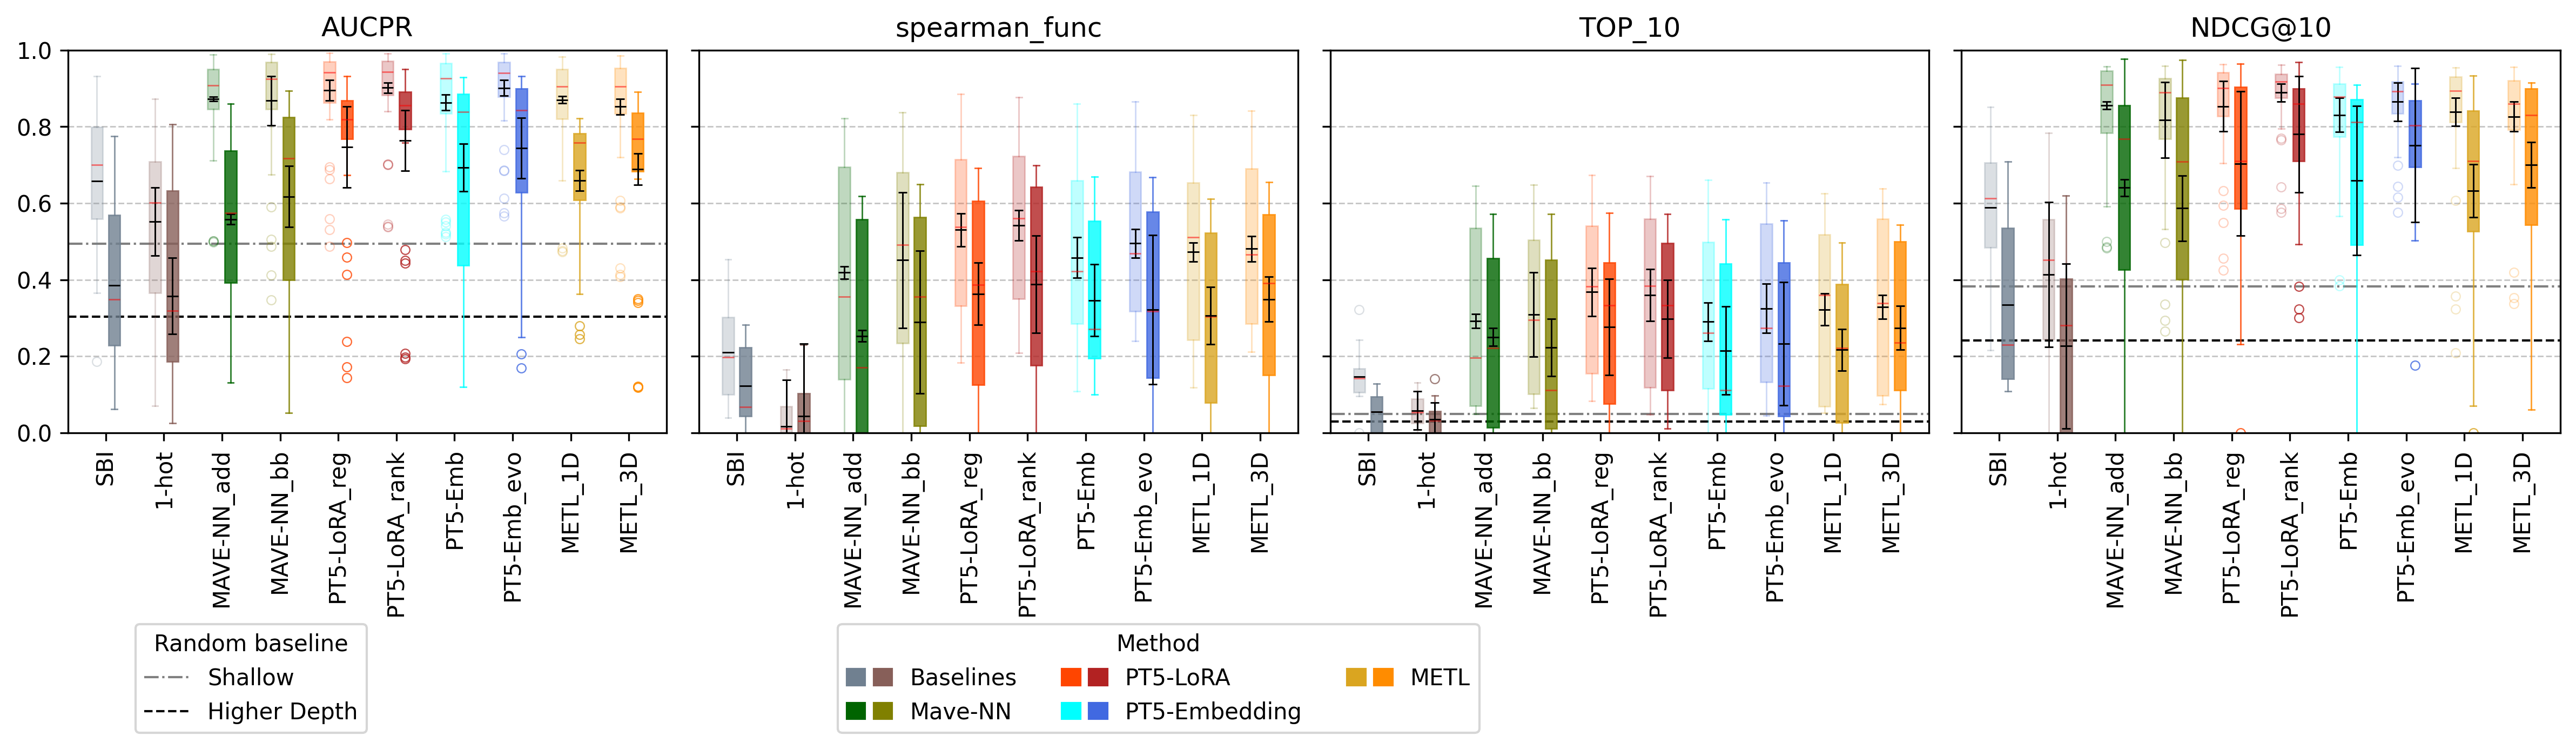

In [17]:
plot_multi_model_multi_metric_DeePEn(models, files, ["AUCPR", "spearman_func", "TOP_10", "NDCG@10"])

### Fig. 4

In [18]:
from sklearn.metrics import ndcg_score
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy import stats

from collections import Counter

from matplotlib.colors import LinearSegmentedColormap

In [19]:
# plot 
def map_uniform_targets_to_height_binary(
    targets: np.ndarray,
    binary: np.ndarray
) -> tuple[np.ndarray, dict[float, int]]:
    # Check if binary and targets arrays have the same length
    if len(targets) != len(binary):
        raise ValueError("The length of 'targets' and 'binary' arrays must be the same.")

    # Separate targets based on binary value
    targets_0 = targets[binary == 0]
    targets_1 = targets[binary == 1]

    # Scale target values for visual fidelity in each binary category
    unique_targets_0 = np.unique(targets_0)
    unique_targets_1 = np.unique(targets_1)

    uniform_unique_targets_0 = np.linspace(-1.0, -0.01, len(unique_targets_0))
    uniform_unique_targets_1 = np.linspace(0.01, 1.0, len(unique_targets_1))

    target_to_uniform_target_0 = {t: ut for t, ut in zip(unique_targets_0, uniform_unique_targets_0)}
    target_to_uniform_target_1 = {t: ut for t, ut in zip(unique_targets_1, uniform_unique_targets_1)}

    uniform_targets_0 = np.array([target_to_uniform_target_0[t] for t in targets_0])
    uniform_targets_1 = np.array([target_to_uniform_target_1[t] for t in targets_1])

    # Concatenate the arrays for both binary categories
    uniform_targets = np.zeros_like(targets, dtype=float)
    uniform_targets[binary == 0] = uniform_targets_0
    uniform_targets[binary == 1] = uniform_targets_1

    # Calculate heights for visualization
    uniform_target_to_count = Counter(uniform_targets.tolist())
    uniform_target_to_height = {}
    for uniform_target, count in uniform_target_to_count.items():
        if uniform_target > 0:
            uniform_target_to_height[uniform_target] = 2
        else:
            uniform_target_to_height[uniform_target] = 1

    return uniform_targets, uniform_target_to_height


def generate_image_rows(
    entries: np.ndarray,
    entry_to_height: dict[float, int]
) -> np.ndarray:
    image_rows = []
    for target in entries:
        height = entry_to_height[target]
        for _ in range(height):
            image_rows.append([target])
    return np.array(image_rows)



def plot_ranking_predictions_heatmap(df, runs_ranking_metrics = "Spearman", perfect=True) -> None:
    if perfect:
        num_runs = 1
    else:
        num_runs = 0 
        
    fig, query_to_fig_axes = plt.subplots(1,
            num_runs + 1,
            figsize=(8 * (num_runs + 1), 9)
        )
    
    for index, ranking_metrics in enumerate([runs_ranking_metrics], start=1):
        if perfect:        
            target_ax = query_to_fig_axes[0]
            preds_ax = query_to_fig_axes[1]
        else:
            preds_ax = query_to_fig_axes
            
        target = df["ranking"].to_numpy()
        preds = df["preds"].to_numpy()
        binary = df["binary"].to_numpy()
        
        target_permutation = np.argsort(target, kind="stable")[::-1]
        preds_permutation = np.argsort(preds, kind="stable")[::-1]

        uniform_targets, target_to_height = map_uniform_targets_to_height_binary(target, binary)
    
        sorted_target = uniform_targets[target_permutation]
        sorted_preds = uniform_targets[preds_permutation]

        perfect_image_rows = generate_image_rows(sorted_target, target_to_height)
        preds_image_rows = generate_image_rows(sorted_preds, target_to_height)
        

        image_width = len(perfect_image_rows)

        perfect_image = np.hstack((perfect_image_rows,) * image_width)
        
        # Create custom colormap
        # Define colormaps for negative and positive values
        blues = LinearSegmentedColormap.from_list('Blues', ['navy', 'lightcyan'], N=128)
        reds = LinearSegmentedColormap.from_list('Reds', ['mistyrose', 'crimson'], N=128)

        # Combine the two colormaps
        colors = np.vstack((blues(np.linspace(0, 1, 128)), reds(np.linspace(0, 1, 128))))
        custom_cmap = LinearSegmentedColormap.from_list('CustomBlueRed', colors)
        if perfect:
            target_ax.imshow(
                perfect_image,
                cmap=custom_cmap,
                aspect="equal"
            )
            target_ax.tick_params(
                axis="both",
                which="both",
                bottom=False,
                labelbottom=False,
                left=False,
                labelleft=False
            )
            target_ax.set_title("Perfect Ranking")

        preds_image = np.hstack((preds_image_rows,) * image_width)
        preds_ax.imshow(
            preds_image,
            cmap=custom_cmap,
            aspect="equal"
        )
        preds_ax.tick_params(
            axis="both",
            which="both",
            bottom=False,
            labelbottom=False,
            left=False,
            labelleft=False
        )
        preds_ax.set_title(f"{runs_ranking_metrics}")


In [20]:
from tqdm import tqdm

def precomputed_swaps(array, n):
    """
    Generate a permutation of a given NumPy array by precomputing n single swap pairs,
    then applying them in sequence.

    Parameters:
    array (np.ndarray): The input array to permute.
    n (int): The number of swap pairs to generate and apply.

    Returns:
    np.ndarray: The final array after performing n swaps.
    """
    # Create a copy of the original array to avoid modifying it
    permuted_array = copy.deepcopy(array)
    size = len(permuted_array)

    # Generate swap pairs using vectorized operations
    indices = np.random.choice(size, n*2, replace=True)
    swap_indices = np.column_stack((indices[:n], indices[n:2*n]))

    # Perform the swaps
    for idx1, idx2 in swap_indices:
        permuted_array[idx1], permuted_array[idx2] = permuted_array[idx2], permuted_array[idx1]

    return permuted_array

In [21]:
size = 1000000

pos_share = 0.2

ranking = np.array(range(0,size))

binary = np.zeros(size)
binary[int(size*(1-pos_share)):] = 1

ndcg_ranking = np.zeros(size)
ndcg_ranking[int(size*(1-pos_share)):] = np.linspace(1,3,int(size*pos_share))

#### Randomly Shuffled

In [22]:
np.random.seed(42)

shuffled_ranking = ranking.copy()
np.random.shuffle(shuffled_ranking)

In [23]:
stats.spearmanr(ranking,shuffled_ranking).correlation.round(2)

np.float64(-0.0)

In [24]:
stats.spearmanr(ranking[binary==1],shuffled_ranking[binary==1]).correlation.round(2)

np.float64(0.0)

In [25]:
average_precision_score(binary,shuffled_ranking).round(2)

np.float64(0.2)

In [26]:
ndcg_score([list(ndcg_ranking)], [list(shuffled_ranking)], k = int(size*pos_share*0.1)).round(2)

np.float64(0.14)

In [27]:
round(topx_overlap(pd.Series(ranking), pd.Series(shuffled_ranking), int(size*pos_share*0.1)),2)

0.02

In [28]:
df_in = pd.DataFrame({
    'ranking': ranking,
    'preds': shuffled_ranking,
    'binary': binary    
})

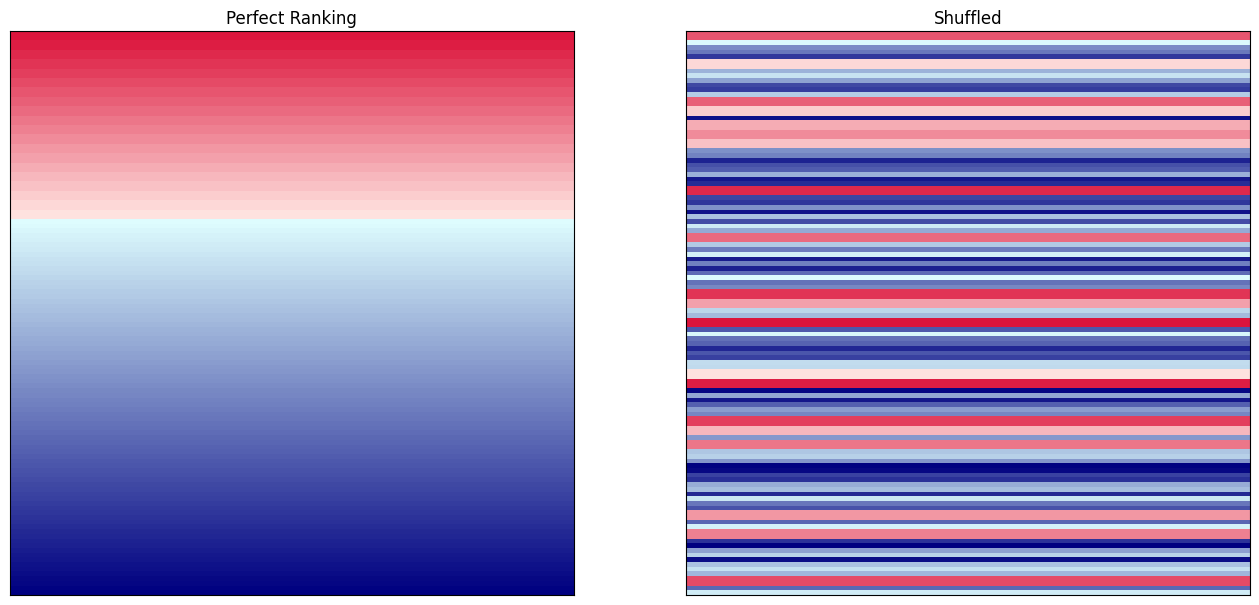

In [29]:
plot_ranking_predictions_heatmap(df_in.iloc[1::10000], "Shuffled")

#### Offset fit block

In [30]:
np.random.seed(45)

unfit_ranking = ranking.copy()
unfit_ranking = np.concatenate((unfit_ranking[:int(size*0.5)], unfit_ranking[int(size*0.7):],unfit_ranking[int(size*0.5):int(size*0.7)]))

swapped_top = precomputed_swaps(unfit_ranking[int(size*0.8):],int(size*0.0355))

unfit_ranking = np.concatenate((unfit_ranking[:int(size*0.8)],swapped_top))

swapped_rest = precomputed_swaps(unfit_ranking[:int(size*0.8)],int(size*0.071))

unfit_ranking = np.concatenate((swapped_rest, unfit_ranking[int(size*0.8):]))

In [31]:
stats.spearmanr(ranking,unfit_ranking).correlation.round(2)

np.float64(0.7)

In [32]:
stats.spearmanr(ranking[binary==1],unfit_ranking[binary==1]).correlation.round(2)

np.float64(0.7)

In [33]:
average_precision_score(binary,unfit_ranking).round(2)

np.float64(0.23)

In [34]:
ndcg_score([list(ndcg_ranking)], [list(unfit_ranking)], k = int(size*pos_share*0.1)).round(2)

np.float64(0.0)

In [35]:
round(topx_overlap(pd.Series(ranking), pd.Series(unfit_ranking), int(size*pos_share*0.1)),2)

0.0

In [36]:
df_in = pd.DataFrame({
    'ranking': ranking,
    'preds': unfit_ranking,
    'binary': binary    
})

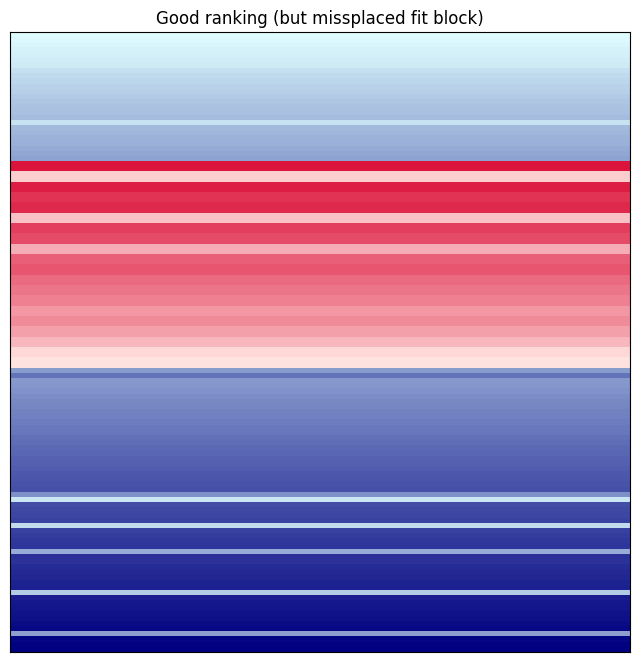

In [37]:
test = plot_ranking_predictions_heatmap(df_in.iloc[0::10000], "Good ranking (but missplaced fit block)", perfect=False)

#### Permutated Ranking (balanced predictor)

In [38]:
np.random.seed(42)

permutated_ranking = ranking.copy()
#tune ndcg & TOP10%

# # swap away top 30% of top 10% functional variants to get correct TOP10%
permutated_ranking = np.concatenate(( # lower part ndcg relevance = 0 starts here up to size * 0.8
                                        permutated_ranking[:int(size*0.794)], ## leave most negatives at the bottom                                   
                                        permutated_ranking[int(size*0.993):int(size*0.999)], ## predict 6% (30% of 20%) negatives close to the top
                                     
                                      # Upper part starts here
                                     permutated_ranking[int(size*0.794):int(size*0.993)],  ## keep the other 14% (70% of 20%) there                                                                          
                                     permutated_ranking[int(size*0.999):] ## keep the very top there
                                     ))


# tune AUCPR
swapped_rest_1 = precomputed_swaps(permutated_ranking[int(size*0.10):int(size*0.95)],int(size*0.18))

permutated_ranking[int(size*0.10):int(size*0.95)] = swapped_rest_1

# tune Spearman_func
swapped_rest_2 = precomputed_swaps(permutated_ranking[int(size*0.8):int(size*0.98)],int(size*0.015))

permutated_ranking[int(size*0.8):int(size*0.98)] = swapped_rest_2

# tune Spearman
swapped_rest_3 = precomputed_swaps(permutated_ranking[:int(size*0.79)],int(size*0.1))

permutated_ranking[:int(size*0.79)] = swapped_rest_3


In [39]:
stats.spearmanr(ranking,permutated_ranking).correlation.round(2)

np.float64(0.7)

In [40]:
stats.spearmanr(ranking[binary==1],permutated_ranking[binary==1]).correlation.round(2)

np.float64(0.7)

In [41]:
average_precision_score(binary,permutated_ranking).round(2)

np.float64(0.7)

In [42]:
ndcg_score([list(ndcg_ranking)], [list(permutated_ranking)], k = int(size*pos_share*0.1)).round(2)

np.float64(0.7)

In [43]:
round(topx_overlap(pd.Series(ranking), pd.Series(permutated_ranking), int(size*pos_share*0.1)),2)

0.7

In [44]:
df_in = pd.DataFrame({
    'ranking': ranking,
    'preds': permutated_ranking,
    'binary': binary    
})

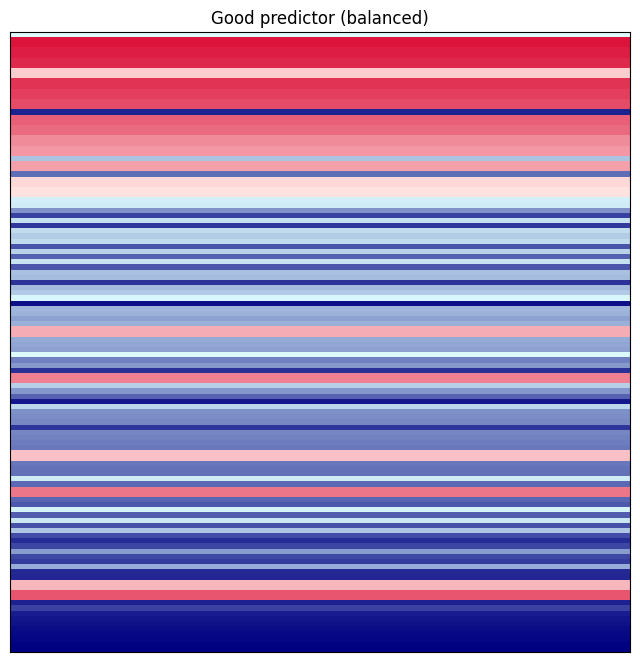

In [45]:
test = plot_ranking_predictions_heatmap(df_in.iloc[5999::10000], "Good predictor (balanced)", perfect=False)

#### Reverse Functional

In [46]:
np.random.seed(42)

reverse_f_ranking = ranking.copy()

#shuffle the functional ones a bit
reverse_f_ranking[int(size*0.8):] = precomputed_swaps(reverse_f_ranking[int(size*0.8):][::-1], int(size*0.03))

#tune aucpr
reverse_f_ranking = precomputed_swaps(reverse_f_ranking,int(size*0.15))

#tune spearman overall
reverse_f_ranking[:int(size*0.8)] = precomputed_swaps(reverse_f_ranking[:int(size*0.8)], int(size*0.03))



In [47]:
stats.spearmanr(ranking,reverse_f_ranking).correlation.round(2)

np.float64(0.7)

In [48]:
stats.spearmanr(ranking[binary==1],reverse_f_ranking[binary==1]).correlation.round(2)

np.float64(-0.43)

In [49]:
average_precision_score(binary,reverse_f_ranking).round(2)

np.float64(0.7)

In [50]:
ndcg_score([list(ndcg_ranking)], [list(reverse_f_ranking)], k = int(size*pos_share*0.1)).round(2)

np.float64(0.37)

In [51]:
round(topx_overlap(pd.Series(ranking), pd.Series(reverse_f_ranking), int(size*pos_share*0.1)),2)

0.03

In [52]:
df_in = pd.DataFrame({
    'ranking': ranking,
    'preds': reverse_f_ranking,
    'binary': binary    
})

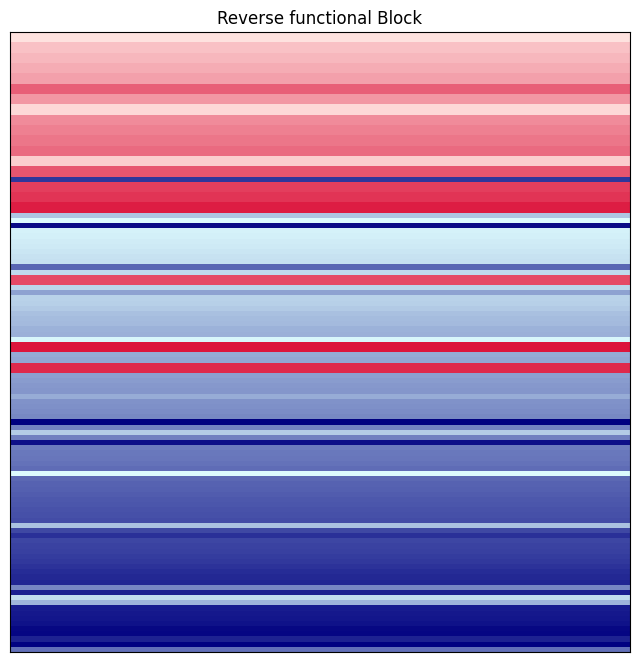

In [53]:
test = plot_ranking_predictions_heatmap(df_in.iloc[1::10000], "Reverse functional Block", perfect=False)

#### NDCG top focussed

In [54]:
def precomputed_swaps_invert(array, n):
    """
    Generate a permutation of a given NumPy array by precomputing n single swap pairs,
    then applying changes in sequence, but only if the array ranking gets worse doing this.

    Parameters:
    array (np.ndarray): The input array to permute.
    n (int): The number of swap pairs to generate and apply.

    Returns:
    np.ndarray: The final array after performing n swaps.
    """
    # Create a copy of the original array to avoid modifying it
    permuted_array = copy.deepcopy(array)
    size = len(permuted_array)

    # Generate swap pairs using vectorized operations
    indices = np.random.choice(size, n*2, replace=True)
    swap_indices = np.column_stack((indices[:n], indices[n:2*n]))

    # Perform the swaps
    for idx1, idx2 in swap_indices:
        if (idx1 > idx2 and permuted_array[idx1] > permuted_array[idx2]
           ) or (
            idx1 < idx2 and permuted_array[idx1] < permuted_array[idx2]):
            
            permuted_array[idx1], permuted_array[idx2] = permuted_array[idx2], permuted_array[idx1]

    return permuted_array

In [55]:
np.random.seed(42)

#start from the balanced predictor
top_10_ranking = permutated_ranking.copy()

#save the indices of top 5% scores (to ignore them in all changes)
top_index = top_10_ranking[:int(size*0.95)]>int(size*0.95)

#perfectly rank all below 0.95
top_10_ranking[:int(size*0.95)][~top_index] = sorted(top_10_ranking[:int(size*0.95)][~top_index])

#tune overall spearman
# take two arrays
#swap between them n times
# to really move most of the lower functional variants away
top_part =  top_10_ranking[int(size*0.8):int(size*0.95)]

swap_lower = 0.33
swap_upper = 0.6

swap_to = top_10_ranking[int(size*swap_lower):int(size*swap_upper)]

# Randomly select indices to swap
n = int(size*0.134)

top_part_selected = top_part[~top_index[int(size*0.8):int(size*0.95)]]
swap_to_selected  = swap_to[~top_index[int(size*swap_lower):int(size*swap_upper)]]

indices_top_part = np.random.choice(len(top_part_selected), n, replace=False)
indices_swap_to = np.random.choice(len(swap_to_selected), n, replace=False)

# Perform the swap
temp = top_part_selected[indices_top_part].copy()
top_part_selected[indices_top_part] = swap_to_selected[indices_swap_to]
swap_to_selected[indices_swap_to] = temp

# Update top_part and top_10_ranking if necessary
top_part[~top_index[int(size*0.8):int(size*0.95)]] = top_part_selected
swap_to[~top_index[int(size*swap_lower):int(size*swap_upper)]] = swap_to_selected

top_10_ranking[int(size*0.8):int(size*0.95)] = top_part
top_10_ranking[int(size*swap_lower):int(size*swap_upper)] = swap_to

# shuffle everything between swap_upper and 0.95
shuffle_index = (~top_index) & (top_10_ranking[:int(size*0.95)] > int(size*swap_upper)) & (top_10_ranking[:int(size*0.95)] < int(size*0.95))

top_10_ranking[:int(size*0.95)][shuffle_index] = precomputed_swaps(top_10_ranking[:int(size*0.95)][shuffle_index], int(size*0.1))

# shuffle everything below swap_lower
shuffle_index = (~top_index) & (top_10_ranking[:int(size*0.95)] < int(size*swap_lower))

top_10_ranking[:int(size*0.95)][shuffle_index] = precomputed_swaps(top_10_ranking[:int(size*0.95)][shuffle_index], int(size*0.1))

# tune spearman_func by reverting some functional pairs below 0.95
top_10_ranking[int(size*0.8):int(size*0.95)][~top_index[int(size*0.8):]] = precomputed_swaps_invert(top_10_ranking[int(size*0.8):int(size*0.95)][~top_index[int(size*0.8):]], int(size*0.3))

# AUCPR is not tuneable here

In [56]:
stats.spearmanr(ranking,top_10_ranking).correlation.round(2)

np.float64(0.7)

In [57]:
stats.spearmanr(ranking[binary==1],top_10_ranking[binary==1]).correlation.round(2)

np.float64(0.29)

In [58]:
average_precision_score(binary,top_10_ranking).round(2)

np.float64(0.38)

In [59]:
ndcg_score([list(ndcg_ranking)], [list(top_10_ranking)], k = int(size*pos_share*0.1)).round(2)

np.float64(0.7)

In [60]:
round(topx_overlap(pd.Series(ranking), pd.Series(top_10_ranking), int(size*pos_share*0.10)),2)

0.7

In [61]:
df_in = pd.DataFrame({
    'ranking': ranking,
    'preds': top_10_ranking,
    'binary': binary    
})

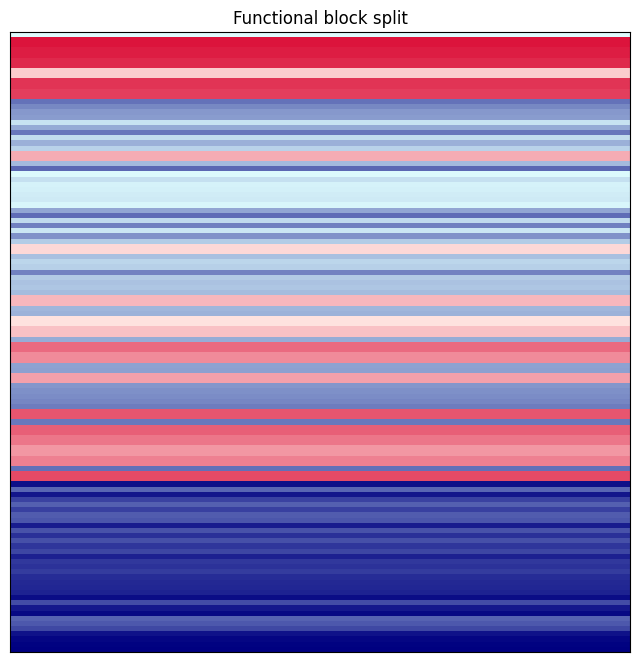

In [62]:
test = plot_ranking_predictions_heatmap(df_in.iloc[5999::10000], "Functional block split", perfect=False)

### Table 1

In [63]:
# # with random_baseline = True and perfect_classifier_baseline = True this cell will take an extended amount of time to compute
# # the perfect_classifier_baseline provides performance of a perfect binary classfier with random ranking among functional variants
# # this is of interest for the NDCG metric 

# def round_to_percent(s):
#     main, error = map(lambda x: float(x.strip()), s.split('±'))
#     main_pct = int(round(main,2) * 100)
#     error_pct = int(round(error,2) * 100)
#     return f"{main_pct} ± {error_pct}"

# df_float = table_multi_model_multi_metric_DeePEn(models,files,["AUCPR", "spearman_func", "TOP_10", "NDCG@10"], 
#                                            random_baseline = True, perfect_classifier_baseline = True, percentage = False, digits = 3)
# df_float.to_csv("./results/main/random_baseline/DeePEn_Table_1_float.csv", index=False)
# # get percentage values
# df = df_float.copy()
# for m in ["AUCPR", "spearman_func", "TOP_10", "NDCG@10"]:
#     df[m] = df[m].apply(round_to_percent)
# df.to_csv("./results/main/random_baseline/DeePEn_Table_1.csv", index=False)


# alternatively read from file 
df = pd.read_csv("./results/main/random_baseline/DeePEn_Table_1.csv")
# or run without the baselines
# df = table_multi_model_multi_metric_DeePEn(models,files,["AUCPR", "spearman_func", "TOP_10", "NDCG@10"])

df

,method,depth,AUCPR,spearman_func,TOP_10,NDCG@10
0,perfect_classifier_baseline,shallow (5-9),100 ± 0,0 ± 0,10 ± 0,77 ± 0
1,perfect_classifier_baseline,higher depth (10+),100 ± 0,0 ± 0,10 ± 0,77 ± 0
2,random_baseline,shallow (5-9),49 ± 0,0 ± 0,5 ± 0,38 ± 0
3,random_baseline,higher depth (10+),30 ± 0,0 ± 0,3 ± 0,24 ± 0
4,SBI,shallow (5-9),66 ± 0,21 ± 0,15 ± 0,59 ± 0
5,SBI,higher depth (10+),39 ± 0,12 ± 0,6 ± 0,34 ± 0
6,1-hot,shallow (5-9),55 ± 9,2 ± 12,6 ± 5,41 ± 19
7,1-hot,higher depth (10+),36 ± 10,4 ± 19,4 ± 4,23 ± 22
8,MAVE-NN_add,shallow (5-9),87 ± 1,42 ± 2,28 ± 2,86 ± 1
9,MAVE-NN_add,higher depth (10+),56 ± 1,25 ± 1,25 ± 2,64 ± 2


### Table 2

In [64]:
def dataset_size(data):
    
    print(data)
    
    df_raw = pd.read_csv("./data/raw/" + data + "/DMS_raw.csv", low_memory=False) 

    df_raw = df_raw[df_raw.set!="wt"]    
    df_raw = df_raw.drop('mutated_sequence', axis=1)
    df_raw = df_raw.drop('set', axis=1)

    df_func = df_raw[df_raw.DMS_score_bin == 1].copy()
    
    if "GFP" in data:
        buckets = [range(1,4), range(4,5), range(5,8), range(8,100)]
        distance_wt  = ["1-3", "4", "5-7", "8-" + str(df_raw.mutation_depth.max())]
    else:
        buckets = [range(1,4), range(4,5), range(5,10), range(10,100)]
        distance_wt  = ["1-3", "4", "5-9", "10-" + str(df_raw.mutation_depth.max())]
    split  = ["Training", "Validation", "Test", "Test"]



    res = pd.DataFrame(columns=["Split","Distance from wildtype","Number of seq","Number of functional seq","Share of functional seq"])

    for idx , b in enumerate(buckets):
        new_row = pd.DataFrame([{'Split' : split[idx],
                                 'Distance from wildtype' : distance_wt[idx],
                                 'Number of seq' : len(df_raw[(df_raw.mutation_depth >= np.min(b)) & (df_raw.mutation_depth <= np.max(b))]),
                                 'Number of functional seq' : len(df_func[(df_func.mutation_depth >= np.min(b)) & (df_func.mutation_depth <= np.max(b))]),
                                 'Share of functional seq' :  round(len(df_func[(df_func.mutation_depth >= np.min(b)) & (df_func.mutation_depth <= np.max(b))]) / 
                                                                 len(df_raw[(df_raw.mutation_depth >= np.min(b)) & (df_raw.mutation_depth <= np.max(b))]),3) *100
                                }])
        res = pd.concat([res.dropna(how='all', axis=1),new_row], ignore_index=True)
    
    return(res)
    


In [65]:
dataset_size(files[0])

CAPSD_AAV2S_Sinai_2021


,Split,Distance from wildtype,Number of seq,Number of functional seq,Share of functional seq
0,Training,1-3,18271,10093,55.2
1,Validation,4,6646,4504,67.8
2,Test,5-9,13942,7132,51.2
3,Test,10-28,3469,183,5.3


In [66]:
dataset_size(files[1])

GFP_AEQVI_Sarkisyan_2016


,Split,Distance from wildtype,Number of seq,Number of functional seq,Share of functional seq
0,Training,1-3,26197,21594,82.4
1,Validation,4,9387,5104,54.4
2,Test,5-7,13649,3315,24.3
3,Test,8-15,2481,73,2.9


In [67]:
dataset_size(files[2])

HIS7_YEAST_Pokusaeva_2019


,Split,Distance from wildtype,Number of seq,Number of functional seq,Share of functional seq
0,Training,1-3,9270,8198,88.4
1,Validation,4,25927,21177,81.7
2,Test,5-9,429661,283521,66.0
3,Test,10-28,31279,17308,55.3


In [68]:
dataset_size(files[3])

PHOT_CHLRE_Chen_2023


,Split,Distance from wildtype,Number of seq,Number of functional seq,Share of functional seq
0,Training,1-3,3276,2852,87.1
1,Validation,4,3565,2859,80.2
2,Test,5-9,123206,66552,54.0
3,Test,10-15,37482,11505,30.7
